# Лабораторная работа 1

1) Классификация данных методом k ближайших соседей ( kNN)

2) Классификация данных методом опорных векторов (SVM)

Вариант 1: набор данных CIFAR-10

Лабораторные работы можно выполнять с использованием сервиса Google Colaboratory (https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) или на локальном компьютере. 

## 1. Классификация данных методом k ближайших соседей ( kNN)

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scripts.data_utils import load_CIFAR10


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

1.1 Скачайте данные в соответсвии с заданием.

CIFAR-10 по ссылке https://www.cs.toronto.edu/~kriz/cifar.html
или используйте  команду !bash get_datasets.sh (google colab, local ubuntu)

MNIST 
sklearn.datasets import load_digits
digits = load_digits()

In [2]:
cifar10_dir = 'scripts/datasets/cifar-10-batches-py'

try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


1.2 Выведите несколько примеров изображений из обучающей выборки для каждого класса.



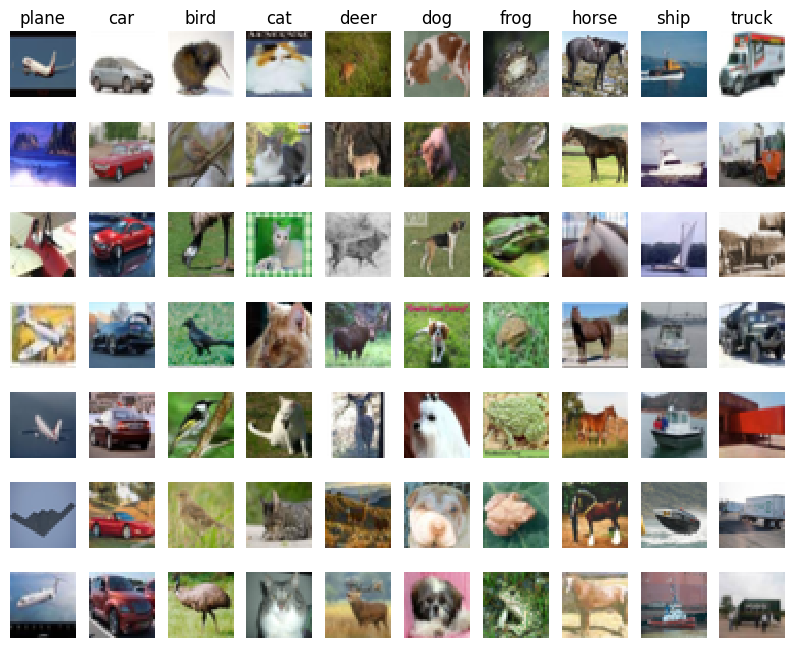

In [3]:
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7

for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)

plt.show()

1.3 Разделите данные на обучающу и тестовую выборки (X_train, y_train, X_test, y_test). Преобразуйте каждое изображение в одномерный массив. 

In [4]:
num_training = 10000
mask = list(range(num_training))
X_train_knn = X_train[mask]
y_train_knn = y_train[mask]

num_test = 2000
mask = list(range(num_test))
X_test_knn = X_test[mask]
y_test_knn = y_test[mask]

X_train_knn = np.reshape(X_train_knn, (X_train_knn.shape[0], -1))
X_test_knn = np.reshape(X_test_knn, (X_test_knn.shape[0], -1))

print('Training data shape: ', X_train_knn.shape)
print('Training labels shape: ', y_train_knn.shape)
print('Test data shape: ', X_test_knn.shape)
print('Test labels shape: ', y_test_knn.shape)

Training data shape:  (10000, 3072)
Training labels shape:  (10000,)
Test data shape:  (2000, 3072)
Test labels shape:  (2000,)


1.4 Напишите реализацию классификатора в скрипте /classifiers/k_nearest_neighbor.py и обучите его на сформированной выборке. 

In [5]:
from scripts.classifiers import KNearestNeighbor

classifier = KNearestNeighbor()
classifier.train(X_train_knn, y_train_knn)

1.5 Выполните классификацию на тестовой выборке

In [6]:
dists = classifier.compute_distances_no_loops(X_test_knn)
y_test_pred = classifier.predict_labels(dists, k=3)
print('Classified images: ', len(y_test_pred))

Classified images:  2000


1.6 Визуализируйте матрицу расстояний для каждого изображения из тестовой выборки до изображений из обучающей выборки. 


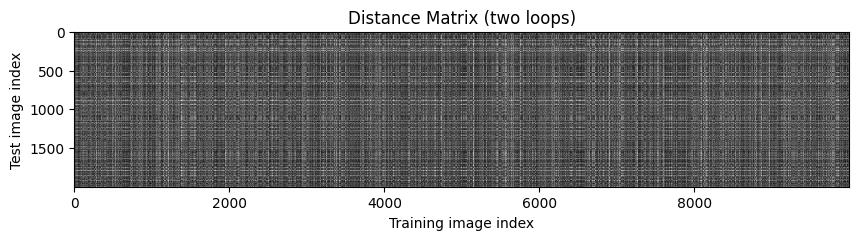

In [7]:
dists_2_loops = classifier.compute_distances_two_loops(X_test_knn)
plt.imshow(dists_2_loops)
plt.xlabel('Training image index')
plt.ylabel('Test image index')
plt.title('Distance Matrix (two loops)')
plt.show()

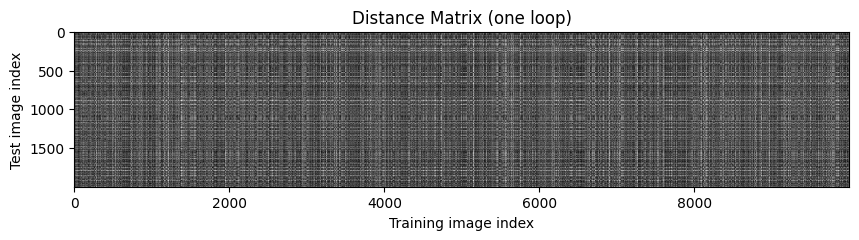

In [8]:
dists_1_loop = classifier.compute_distances_one_loop(X_test_knn)
plt.imshow(dists_1_loop)
plt.xlabel('Training image index')
plt.ylabel('Test image index')
plt.title('Distance Matrix (one loop)')
plt.show()

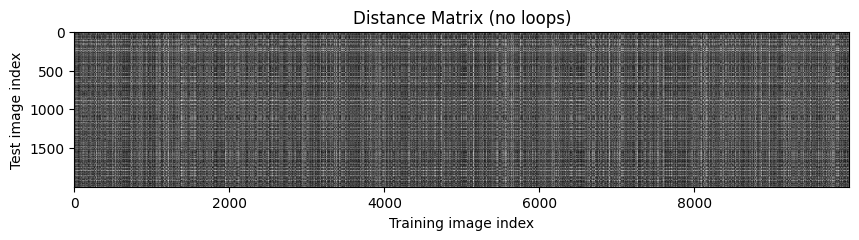

In [9]:
plt.imshow(dists)
plt.xlabel('Training image index')
plt.ylabel('Test image index')
plt.title('Distance Matrix (no loops)')
plt.show()


1.7 Посчитайте долю правильно классифицированных изображений из тестовой выборки.


In [10]:
num_test = X_test_knn.shape[0]
num_correct = np.sum(y_test_pred == y_test_knn)
accuracy = float(num_correct) / num_test
print(f"Accuracy: {accuracy} ({num_correct}/{num_test})")

Accuracy: 0.2705 (541/2000)


1.8 Постройте график зависимости доли правильно классифицированных изображений от числа соседей, используемых при классификации.

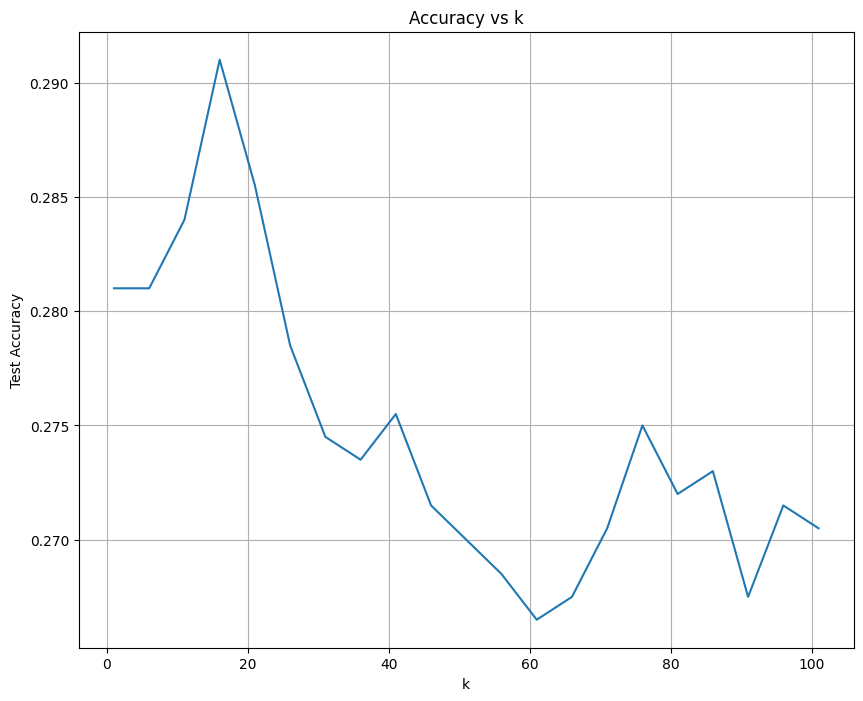

In [11]:
k_choices = range(1, 102, 5)
accuracies = []

for k in k_choices:
    y_pred = classifier.predict_labels(dists, k=k)
    num_correct = np.sum(y_pred == y_test_knn)
    accuracy = float(num_correct) / num_test
    accuracies.append(accuracy)

plt.plot(k_choices, accuracies)
plt.title('Accuracy vs k')
plt.xlabel('k')
plt.ylabel('Test Accuracy')
plt.grid(True)
plt.show()

1.9 Выберите лучшее значение параметра k на основе кросс-валидации.


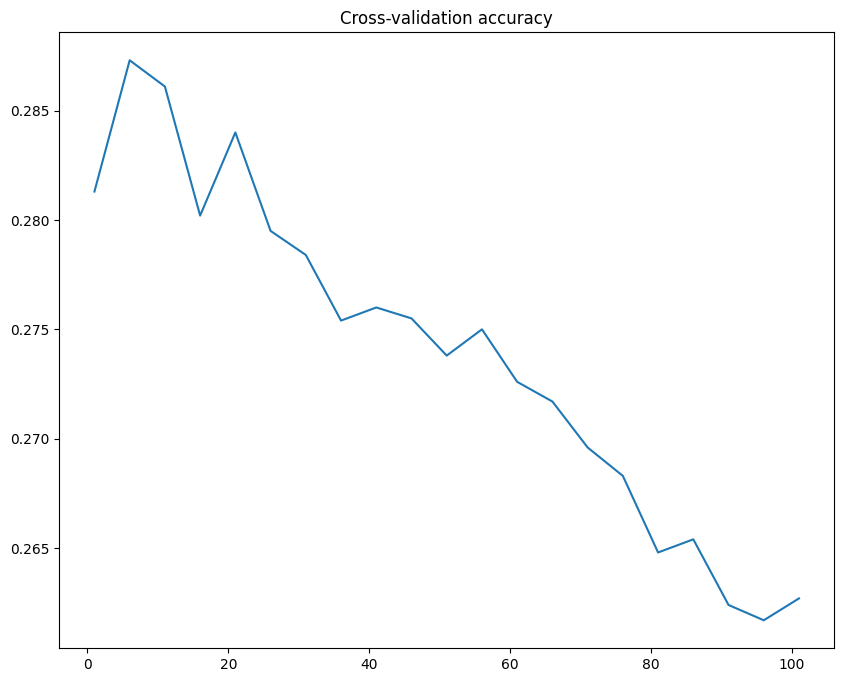


Best k:  6


In [12]:
num_folds = 5
k_choices = range(1, 102, 5)

X_train_folds = np.array_split(X_train_knn, num_folds)
y_train_folds = np.array_split(y_train_knn, num_folds)

k_to_accuracies = {}

for k in k_choices:
    k_to_accuracies[k] = []
    for i in range(num_folds):
        X_train_cv = np.concatenate([X_train_folds[j] for j in range(num_folds) if j != i])
        y_train_cv = np.concatenate([y_train_folds[j] for j in range(num_folds) if j != i])
        X_val_cv = X_train_folds[i]
        y_val_cv = y_train_folds[i]

        classifier.train(X_train_cv, y_train_cv)
        dists_cv = classifier.compute_distances_no_loops(X_val_cv)
        y_val_pred = classifier.predict_labels(dists_cv, k=k)
        
        accuracy = np.mean(y_val_pred == y_val_cv)
        k_to_accuracies[k].append(accuracy)

accuracies_mean = [np.mean(k_to_accuracies[k]) for k in k_choices]
plt.plot(k_choices, accuracies_mean)
plt.title('Cross-validation accuracy')
plt.show()

best_k = k_choices[np.argmax(accuracies_mean)]
print("\nBest k: ", best_k)


1.10 Переобучите и протестируйте классификатор с использованием выбранного значения k.



In [13]:
classifier.train(X_train_knn, y_train_knn)
y_test_pred = classifier.predict(X_test_knn, k=best_k)
num_correct = np.sum(y_test_pred == y_test_knn)
final_accuracy = float(num_correct) / num_test
print(f'Final accuracy (k={best_k}): {final_accuracy} ({num_correct}/{num_test})')

Final accuracy (k=6): 0.281 (562/2000)


1.11 Сделайте выводы по результатам 1 части задания.

В ходе выполнения задания 1 был реализован и исследован классификатор k-ближайших соседей на наборе данных CIFAR-10, где итоговая точность на тестовой выборке составила 28%. Полученный результат существенно превышает порог случайного угадывания (10%), что подтверждает применимость k-NN как базового метода, однако такая точность остается недостаточной для реальных задач компьютерного зрения, так как метрика L2 сравнивает пиксели напрямую без учета семантических свойств объектов. Использование кросс-валидации по 5 фолдам позволило определить оптимальное значение k=6, что обеспечило рост точности с 27% (при малых k) до финальных 28%. Это доказывает эффективность подбора гиперпараметров через кросс-валидацию, так как найденное значение k позволило модели лучше сглаживать шум в данных и показать более надежный и высокий результат на контрольной выборке.

## 2.  Классификация данных методом опорных векторов (SVM)

2.1 Разделите данные на обучающую, тестовую и валидационную выборки. Преобразуйте каждое изображение в одномерный массив. Выведите размеры выборок.

In [14]:
num_training = 9000
mask = list(range(num_training))
X_train_svm = X_train[mask]
y_train_svm = y_train[mask]

num_validation = 1000
mask = list(range(num_training, num_training + num_validation))
X_val_svm = X_train[mask]
y_val_svm = y_train[mask]

num_test = 2000
mask = list(range(num_test))
X_test_svm = X_test[mask]
y_test_svm = y_test[mask]

X_train_svm = np.reshape(X_train_svm, (X_train_svm.shape[0], -1))
X_val_svm = np.reshape(X_val_svm, (X_val_svm.shape[0], -1))
X_test_svm = np.reshape(X_test_svm, (X_test_svm.shape[0], -1))

print('Training data shape: ', X_train_svm.shape)
print('Training labels shape: ', y_train_svm.shape)
print('Validation data shape: ', X_val_svm.shape)
print('Validation labels shape: ', y_val_svm.shape)
print('Test data shape: ', X_test_svm.shape)
print('Test labels shape: ', y_test_svm.shape)

Training data shape:  (9000, 3072)
Training labels shape:  (9000,)
Validation data shape:  (1000, 3072)
Validation labels shape:  (1000,)
Test data shape:  (2000, 3072)
Test labels shape:  (2000,)


2.2 Проведите предварительную обработку данных, путем вычитания среднего изображения, рассчитанного  по обучающей выборке.

2.3 Чтобы далее не учитывать смещение (свободный член b), добавьте дополнитульную размерность к массиву дынных и заполните ее 1.

[131.99744444 136.90011111 133.26188889 131.33122222 136.22188889
 132.50266667 132.23822222 137.00688889 133.18522222 133.01      ]


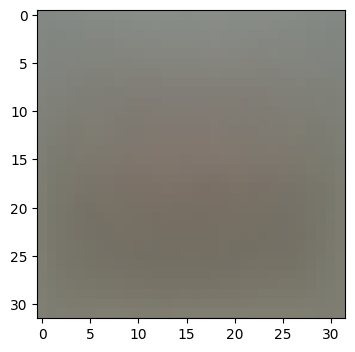

(9000, 3073) (1000, 3073) (2000, 3073)


In [15]:
mean_image = np.mean(X_train_svm, axis=0)
print(mean_image[:10]) 
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) 
plt.show()


X_train_svm -= mean_image
X_val_svm -= mean_image
X_test_svm -= mean_image



X_train_svm = np.hstack([X_train_svm, np.ones((X_train_svm.shape[0], 1))])
X_val_svm = np.hstack([X_val_svm, np.ones((X_val_svm.shape[0], 1))])
X_test_svm = np.hstack([X_test_svm, np.ones((X_test_svm.shape[0], 1))])


print(X_train_svm.shape, X_val_svm.shape, X_test_svm.shape)

2.4 Реализуйте loss-функции в scripts/classifiers/linear_svm.py



In [16]:
num_dev = 500
indices = np.random.choice(X_train_svm.shape[0], num_dev, replace=False)

X_dev = X_train_svm[indices]
y_dev = y_train_svm[indices]

print('X_dev shape: ', X_dev.shape)
print('y_dev shape: ', y_dev.shape)

X_dev shape:  (500, 3073)
y_dev shape:  (500,)


In [17]:

from scripts.classifiers.linear_svm import svm_loss_naive, svm_loss_vectorized
import time


W = np.random.randn(3073, 10) * 0.0001 

loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.000005)
print('loss: %f' % (loss, ))

loss: 8.919192



2.5 Убедитесь, что вы верно реализовали расчет градиента, сравнив с реализацией численными методами (код приведен ниже).

In [18]:

loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.0)

from scripts.gradient_check import grad_check_sparse
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)


loss, grad = svm_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)

numerical: 19.904780 analytic: 19.904780, relative error: 6.181308e-12
numerical: 20.636327 analytic: 20.636327, relative error: 4.862437e-12
numerical: 3.733848 analytic: 3.733848, relative error: 5.524836e-11
numerical: 6.635093 analytic: 6.635093, relative error: 3.962940e-11
numerical: 4.598281 analytic: 4.598281, relative error: 2.547813e-11
numerical: 16.535963 analytic: 16.535963, relative error: 9.316441e-12
numerical: -49.550743 analytic: -49.550743, relative error: 1.050526e-12
numerical: -7.128800 analytic: -7.128800, relative error: 4.981682e-11
numerical: -30.707384 analytic: -30.707384, relative error: 5.505671e-12
numerical: 6.212295 analytic: 6.212295, relative error: 5.638850e-12
numerical: 10.198060 analytic: 10.198060, relative error: 4.894359e-12
numerical: 4.057981 analytic: 4.057981, relative error: 3.310023e-11
numerical: -0.027071 analytic: -0.027071, relative error: 3.969324e-09
numerical: -54.561295 analytic: -54.561295, relative error: 6.535770e-12
numerical:

2.6 Сравните svm_loss_naive и svm_loss_vectorized реализации

In [19]:
tic = time.time()
_, grad_naive = svm_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss and gradient: computed in %fs' % (toc - tic))

tic = time.time()
_, grad_vectorized = svm_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss and gradient: computed in %fs' % (toc - tic))

difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('difference: %f' % difference)

Naive loss and gradient: computed in 0.048809s
Vectorized loss and gradient: computed in 0.002462s
difference: 0.000000


2.7 Реализуйте стохастический градиентный спуск в /classifiers/linear_classifier.py . Реализуйте методы train() и predict() и запустите следующий код

In [20]:
from scripts.classifiers import LinearSVM
svm = LinearSVM()
tic = time.time()
loss_hist = svm.train(X_train_svm, y_train_svm, learning_rate=1e-7, reg=2.5e4,
                      num_iters=1500, verbose=True)
toc = time.time()
print('That took %fs' % (toc - tic))

iteration 0 / 1500: loss 786.982221
iteration 100 / 1500: loss 287.031497
iteration 200 / 1500: loss 108.201625
iteration 300 / 1500: loss 43.188668
iteration 400 / 1500: loss 18.576631
iteration 500 / 1500: loss 9.821470
iteration 600 / 1500: loss 6.635345
iteration 700 / 1500: loss 5.846895
iteration 800 / 1500: loss 5.408995
iteration 900 / 1500: loss 5.367864
iteration 1000 / 1500: loss 4.878501
iteration 1100 / 1500: loss 5.492094
iteration 1200 / 1500: loss 4.620610
iteration 1300 / 1500: loss 5.134616
iteration 1400 / 1500: loss 5.089583
That took 4.997573s


In [21]:
y_train_pred = svm.predict(X_train_svm)
print('training accuracy: %f' % (np.mean(y_train_svm == y_train_pred), ))
y_val_pred = svm.predict(X_val_svm)
print('validation accuracy: %f' % (np.mean(y_val_svm == y_val_pred), ))

training accuracy: 0.390444
validation accuracy: 0.374000


2.8 С помощью кросс-валидации выберите значения параметров скорости обучения и регуляризации. В кросс-валидации используйте обучающую и валидационную выборки. Оцените accuracy на тестовой выборке.

In [25]:
results = {}
best_val = -1
best_svm = None

learning_rates = [1e-7, 5e-5]
regularization_strengths = [2.5e4, 5e4]

for lr in learning_rates:
    for reg in regularization_strengths:
        svm = LinearSVM()
        
        svm.train(X_train_svm, y_train_svm, learning_rate=lr, reg=reg,
                  num_iters=1500, verbose=False)

        y_train_pred = svm.predict(X_train_svm)
        train_accuracy = np.mean(y_train_svm == y_train_pred)

        y_val_pred = svm.predict(X_val_svm)
        val_accuracy = np.mean(y_val_svm == y_val_pred)

        results[(lr, reg)] = (train_accuracy, val_accuracy)

        if val_accuracy > best_val:
            best_val = val_accuracy
            best_svm = svm

for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e | reg %e | train accuracy: %f | val accuracy: %f' % (lr, reg, train_accuracy, val_accuracy))
    
print('Best validation accuracy achieved during cross-validation: %f' % best_val)

y_test_pred = best_svm.predict(X_test_svm)
num_correct = np.sum(y_test_pred == y_test_svm)
final_accuracy = float(num_correct) / num_test
print(f'Final accuracy: {final_accuracy} ({num_correct}/{num_test})')

lr 1.000000e-07 | reg 2.500000e+04 | train accuracy: 0.380778 | val accuracy: 0.362000
lr 1.000000e-07 | reg 5.000000e+04 | train accuracy: 0.374778 | val accuracy: 0.352000
lr 5.000000e-05 | reg 2.500000e+04 | train accuracy: 0.061000 | val accuracy: 0.073000
lr 5.000000e-05 | reg 5.000000e+04 | train accuracy: 0.100111 | val accuracy: 0.104000
Best validation accuracy achieved during cross-validation: 0.362000
Final accuracy: 0.358 (716/2000)


2.9 Сделайте выводы по второй части задания

В ходе выполнения второго задания был реализован и исследован линейный классификатор на основе метода опорных векторов, итоговая точность которого на тестовой выборке составила 35.8%, что является существенным улучшением по сравнению с результатом метода k-ближайших соседей (28%). Такое преимущество обусловлено тем, что в отличие от подхода k-NN, который просто сопоставляет тестовые примеры с ближайшими пиксельными аналогами из обучающей выборки, SVM в процессе обучения находит оптимальные разделяющие гиперплоскости. Применение кросс-валидации позволило выявить наиболее эффективные гиперпараметры обучения (lr=1e−07, reg=2.5e+04). Несмотря на то, что предварительная обработка данных через вычитание среднего изображения и добавление дополнительной размерности значительно повысили качество классификации и скорость сходимости по сравнению с k-NN, итоговая точность всё еще остается ограниченной из-за линейной природы классификатора.